In [1]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder

from utils_analysis import ParticleCode, load_dataset
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

sys.path.insert(0, '../tools/')
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match


In [2]:
# Load datasets 
n_files = 100
location = "nersc"
type="mr6"
df = load_dataset(n_files,location, type)
# Create a caf reader
caf_reader = CafReader(df)
pdg_tab = ParticleCode()

Reading  100  files gk
Location selected nersc
Openning MiniRun 6 CAFs


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:11<00:00,  1.31s/it]


In [3]:
#dimensions of the detector
anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
#Fiducial Volume
tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163


In [4]:
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos=(
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
        ),
    end_pos=(
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
        )

    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    cosL=  abs(dz/track_length)
    return cosL


In [18]:
num_neutrinos_fv_r=0 # in fv
num_neutrinos_fv_t=0 # in fv
num_neutrinos_signal_t=0
#num_neutrinos_fv_tt =0

count_reco=0
count_match_FV=0

filtered_data = []

for ev in range(len(df)):
    #iterate over events 
    ev_data=df.iloc[ev]

    #initialize an array to store signal 
    signal =  np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)
    
    #true mask cc numu-ar in fv
    mask_fv_t = (
    (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
    (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
    (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
    (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
    (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist) &
    (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) &
    (ev_data['rec.mc.nu.iscc']==1) &
    (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)  
    )

    #make signal equal to true mask 
    signal[mask_fv_t]=True

    #iterate over the interactions 
    for ix in range(ev_data['rec.mc.nu..length']):
         if (mask_fv_t[ix]==True): #only the ones that are in mask 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix==0 else 0
            for ip in range(n_pre,n_pre + n_particles):
                pdg= ev_data['rec.mc.nu.prim.pdg'][ip]    
                if pdg == pdg_tab.muon: 
                    
                    Elep= ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL=calculate_cosL(ev_data,ip)
                    if (cosL<0.9 and Elep<1):
                        signal[ix] = False

    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    num_neutrinos_fv_r += np.sum(mask_fv_r)
    num_neutrinos_fv_t += np.sum(mask_fv_t)
    num_neutrinos_signal_t+= np.sum(signal)
    
    for ixn_index, value in enumerate(mask_fv_r):
        if value:  
            count_reco +=1 #count num of vertices in fv
            n_int = ev_data['rec.common.ixn.dlp.truth..length'][ixn_index]
            if(ixn_index==0):
                n_pre = 0
            else: 
                n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:ixn_index]) 
            max_overlap=0
            best_match_idx=None
            for ip in range(n_pre,n_pre + n_int):
                temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
                temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
                #print(f'this vtx has tem overlap {temp_overlap} in index {temp_tp_ixn}')
                if (temp_overlap> max_overlap):
                    max_overlap = temp_overlap
                    best_match_idx = temp_tp_ixn
            
            if best_match_idx!=None:
                delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.x'][ixn_index])
                delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.y'][ixn_index])
                delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.z'][ixn_index])
                if ((signal[best_match_idx]==True) and 
                    delta_x < 5 and
                    delta_y < 5 and
                    delta_z < 5):
                        count_match_FV+=1
                        filtered_data.append(ev_data)
                    #print('contained')

        else: continue


there are 7008 reco vertices in FV, and 1161 vertices with true interaction match and 1237 true interactions in FV
0.1656678082191781 0.9385610347615198


There are 7008 reco vertices in FV, and 1164 vertices with true interaction match and 1239 true interactions in FV
0.1660958904109589 0.9394673123486683


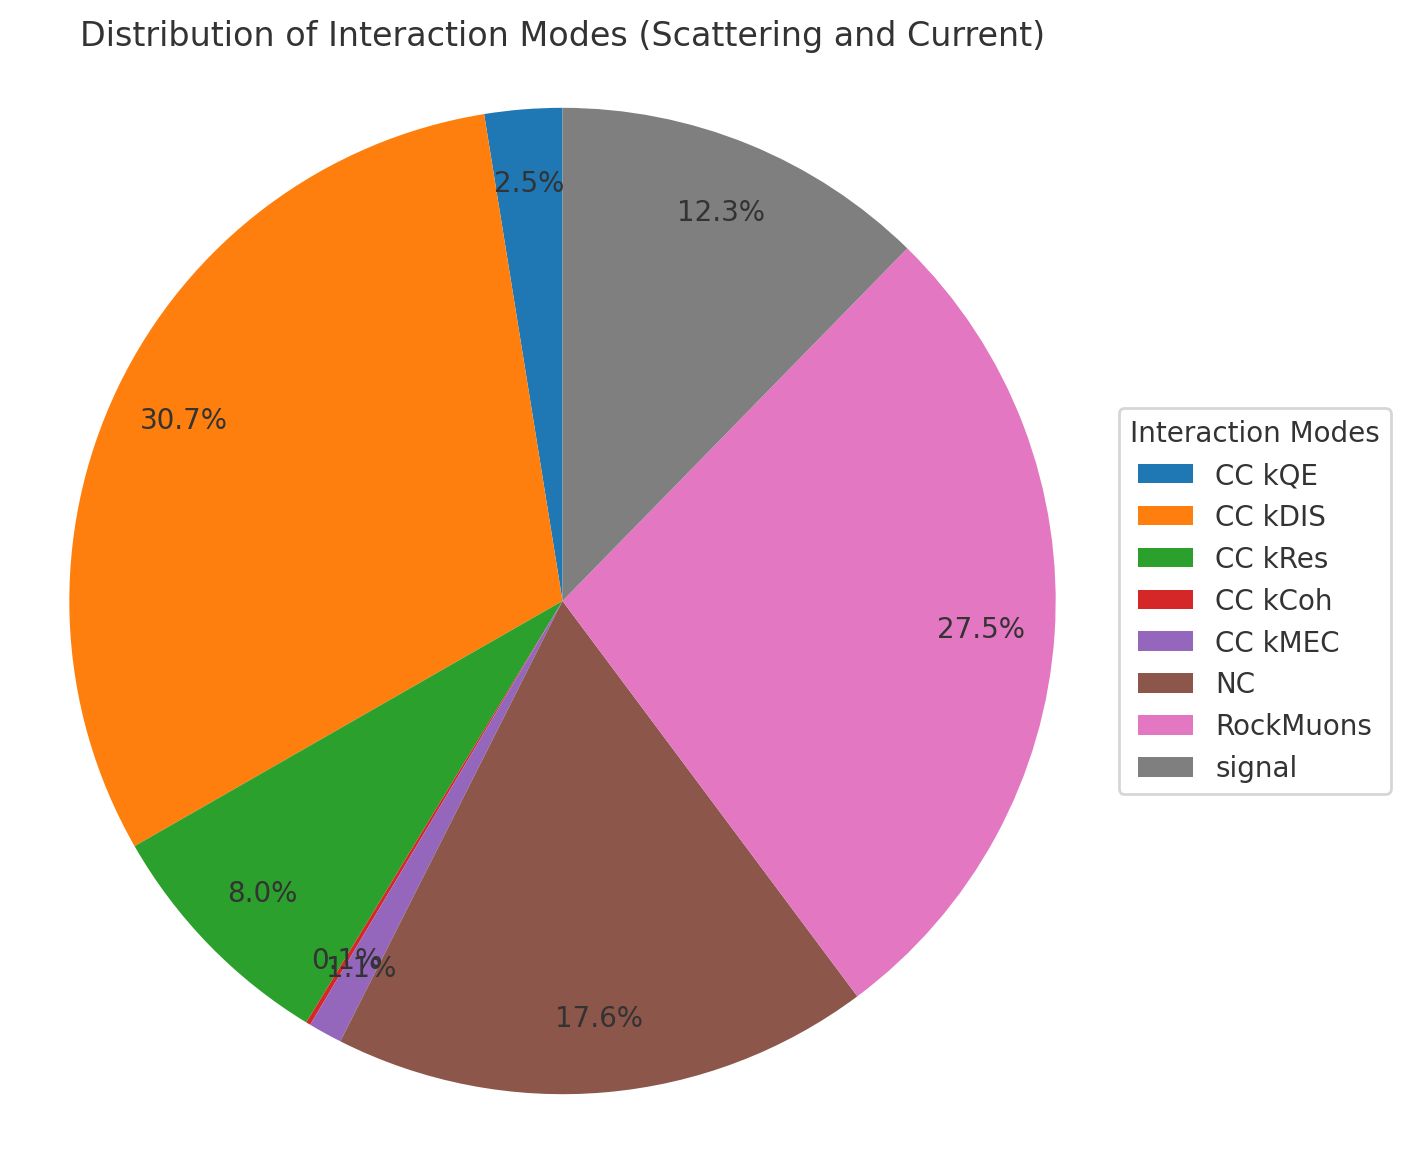

0.1660958904109589 0.9394673123486683


In [33]:
# Neutrino Selection

# Step 1: Define true signal (function TrueSignal)
def true_neutrino_signal(ev_data): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool) 
    mask_t = (
        (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
        (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
        (ev_data['rec.mc.nu.iscc'] == 1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)  
    )
    
    signal[mask_t] = True
    
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]:  # Ensure mask_fv_t is defined
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if pdg == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define reco neutrino signal
def reco_neutrino_signal(ev_data, FV=True):    
    mask_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    return mask_r if FV else None


# Step 3: Find match of reco-true (modified to match Code 2)
def matching(ev_data, vtx_index, signal):
    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_idx = None

    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_ixn

    if best_match_idx is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])

        if signal[best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            return True, best_match_idx
    return False, best_match_idx

# Step 4: Plot interaction type
def plot_interactions(scattering_counters, current_counters, count_match_FV):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Distribution of Interaction Modes (Scattering and Current)')
    plt.axis('equal')
    plt.show()

# Step 5: Efficiency and purity calculation
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    efficiency = count_match_FV / count_reco if count_reco > 0 else 0
    purity = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Constants and initializations
ScatteringMode = {
    'CC kQE': 1, 'CC kDIS': 3,
    'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10
}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}

num_neutrinos_fv_r = 0  # in FV
num_neutrinos_signal_t = 00
count_reco = 0
count_match_FV = 0
filtered_data = []

# Main loop
for ev in range(len(df)):
    ev_data = df.iloc[ev]  # Iterate over events

    # Obtain true and reco signals
    nu_interactions = true_neutrino_signal(ev_data)
    reco_nu_vertices = reco_neutrino_signal(ev_data)

    num_neutrinos_fv_r += np.sum(reco_nu_vertices)
    num_neutrinos_signal_t += np.sum(nu_interactions)

    for vtx_index, value in enumerate(reco_nu_vertices): 
        if value:  
            count_reco += 1  # Count number of vertices in FV
            match, best_match_idx = matching(ev_data, vtx_index, nu_interactions)
            if match: 
                count_match_FV += 1
                filtered_data.append(ev_data)
            elif best_match_idx is not None:
                # Update interaction counters if no match
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )

# Print and plot results
print(f'There are {count_reco} reco vertices in FV, and {count_match_FV} vertices with true interaction match and {num_neutrinos_signal_t} true interactions in FV')
print(count_match_FV / count_reco, count_match_FV / num_neutrinos_signal_t)

plot_interactions(scattering_counters, current_counters, count_match_FV)
e, p = efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t)
print(e, p)


There are 7008 reco vertices in FV, and 1164 vertices with true interaction match and 1239 true interactions in FV
Efficiency: 0.9394673123486683, Purity:  0.1660958904109589


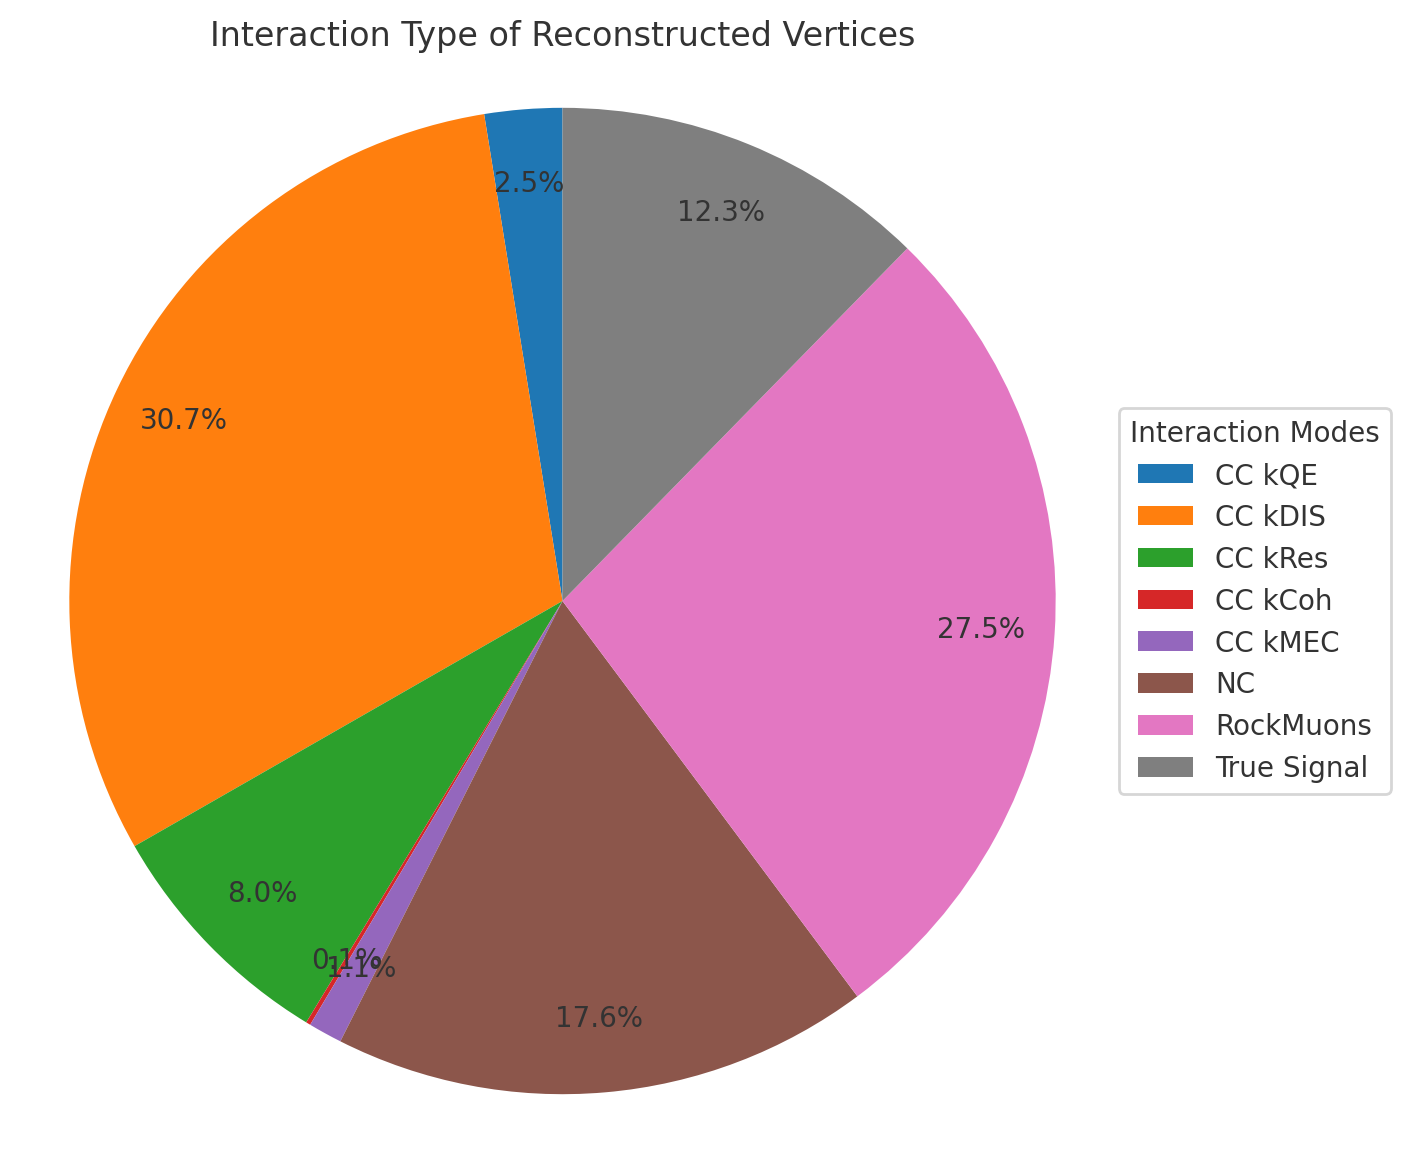

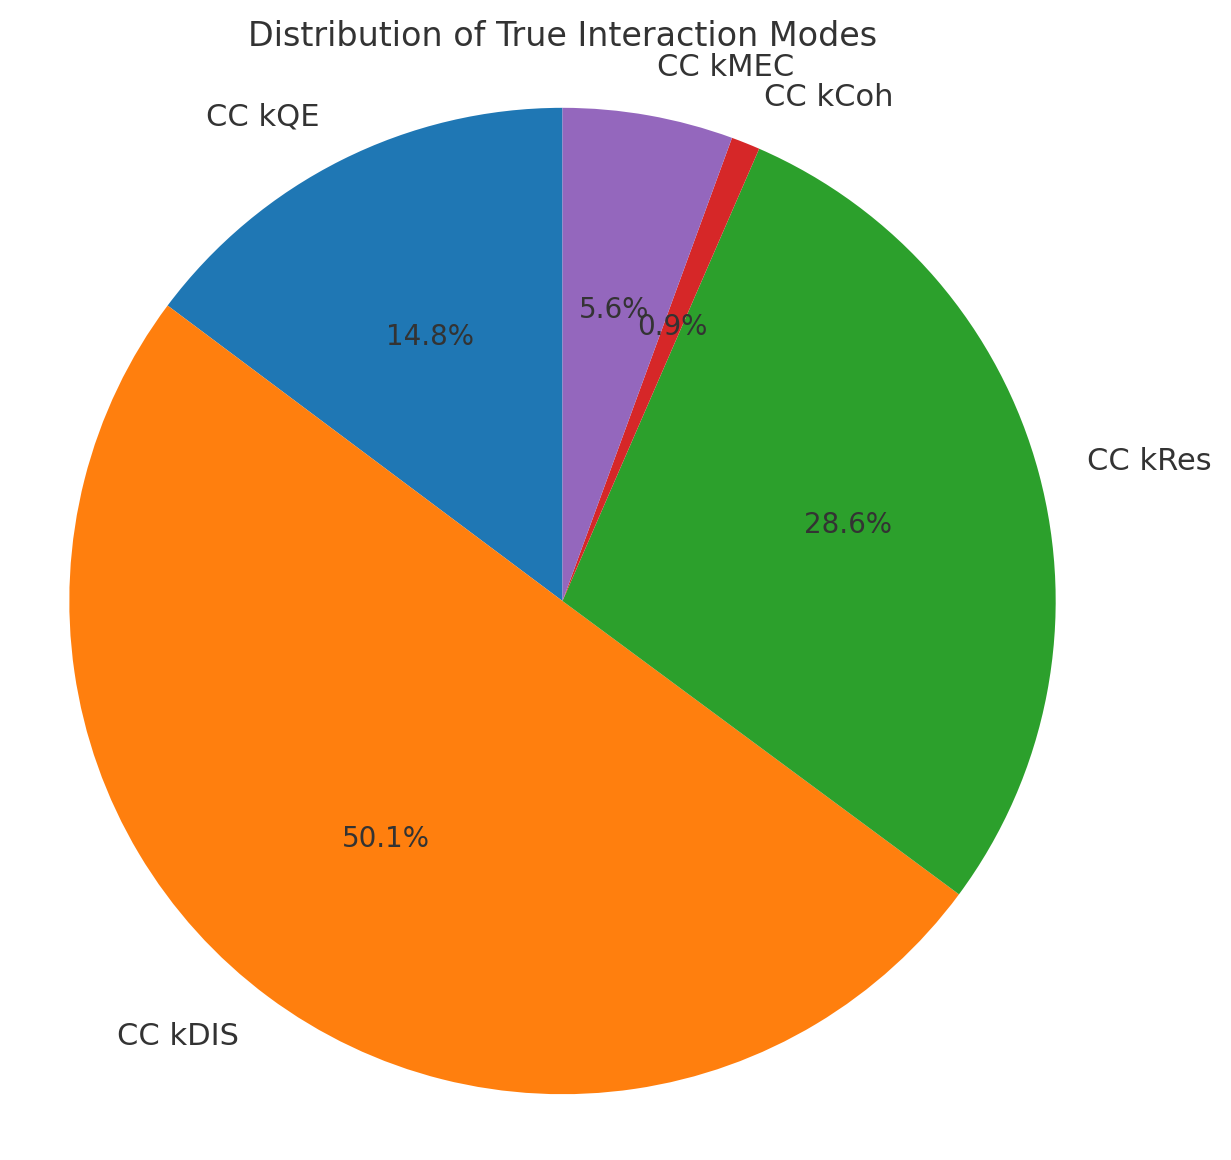

In [47]:
# Neutrino Selection

# Step 1: Define true signal (function TrueSignal)
def true_neutrino_signal(ev_data): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool) 
    mask_t = (
        (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
        (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
        (ev_data['rec.mc.nu.iscc'] == 1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)  
    )
    
    signal[mask_t] = True
    
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]:  # Ensure mask_fv_t is defined
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if pdg == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define reco neutrino signal
def reco_neutrino_signal(ev_data, FV=True):    
    mask_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    return mask_r if FV else None

# Step 3: Find match of reco-true (modified to match Code 2)
def matching(ev_data, vtx_index, signal):
    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_idx = None

    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_ixn

    if best_match_idx is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])

        if signal[best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            return True, best_match_idx
    return False, best_match_idx

#get type of interaction

def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 

    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]

    if ev_data['rec.mc.nu.id'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC

    return scattering_counters, current_counters

# Step 4: Plot interaction type
def plot_interactions(scattering_counters, current_counters, count_match_FV):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

# Step 5: Efficiency and purity calculation
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

def plot_signal_interactions(ScatteringMode, true_counters):
    # Prepare data for the pie chart
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]

    # Plotting the pie chart
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Distribution of True Interaction Modes')
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
    plt.show()

# Constants and initializations
ScatteringMode = {
    'CC kQE': 1, 'CC kDIS': 3,
    'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10
}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
true_counters = {mode: 0 for mode in ScatteringMode.values()}

num_neutrinos_fv_r = 0  # in FV
num_neutrinos_signal_t = 0
count_reco = 0
count_match_FV = 0
filtered_data = []

# Main loop
for ev in range(len(df)):
    ev_data = df.iloc[ev]  # Iterate over events

    # Obtain true and reco signals
    nu_interactions = true_neutrino_signal(ev_data)
    reco_nu_vertices = reco_neutrino_signal(ev_data)

    num_neutrinos_fv_r += np.sum(reco_nu_vertices)
    num_neutrinos_signal_t += np.sum(nu_interactions)

    for vtx_index, value in enumerate(reco_nu_vertices): 
        if value:  
            count_reco += 1  # Count number of vertices in FV
            match, best_match_idx = matching(ev_data, vtx_index, nu_interactions)
            if match: 
                count_match_FV += 1
                filtered_data.append(ev_data)
                true_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1  # Increment the counter for the specific mode    
            elif best_match_idx is not None:
                # Update interaction counters if no match
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )

# Print and plot results
print(f'There are {count_reco} reco vertices in FV, and {count_match_FV} vertices with true interaction match and {num_neutrinos_signal_t} true interactions in FV')
e, p = efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t)
print(f'Efficiency: {e}, Purity:  {p}')

plot_interactions(scattering_counters, current_counters, count_match_FV)
plot_signal_interactions(ScatteringMode, true_counters)
